# Assignment 6

In [1]:
%pip install -q ucimlrepo

In [2]:
import ucimlrepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
individual_household_electric_power_consumption = fetch_ucirepo(id=235) 
  
# data (as pandas dataframes) 
df = individual_household_electric_power_consumption.data.features 

# metadata 
print(individual_household_electric_power_consumption.metadata) 
  
# variable information 
print(individual_household_electric_power_consumption.variables) 

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 235, 'name': 'Individual Household Electric Power Consumption', 'repository_url': 'https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption', 'data_url': 'https://archive.ics.uci.edu/static/public/235/data.csv', 'abstract': 'Measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. Different electrical quantities and some sub-metering values are available.', 'area': 'Physics and Chemistry', 'tasks': ['Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 2075259, 'num_features': 9, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2006, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C58K54', 'creators': ['Georges Hebrail', 'Alice Berard'], 'intro_paper': None, 'additional_info': {'summary': 'This archiv

In [4]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979


In [5]:
# coerce everything to numeric first
for c in ['Global_active_power','Global_reactive_power','Voltage',
          'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [6]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [7]:
display(df.head())

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


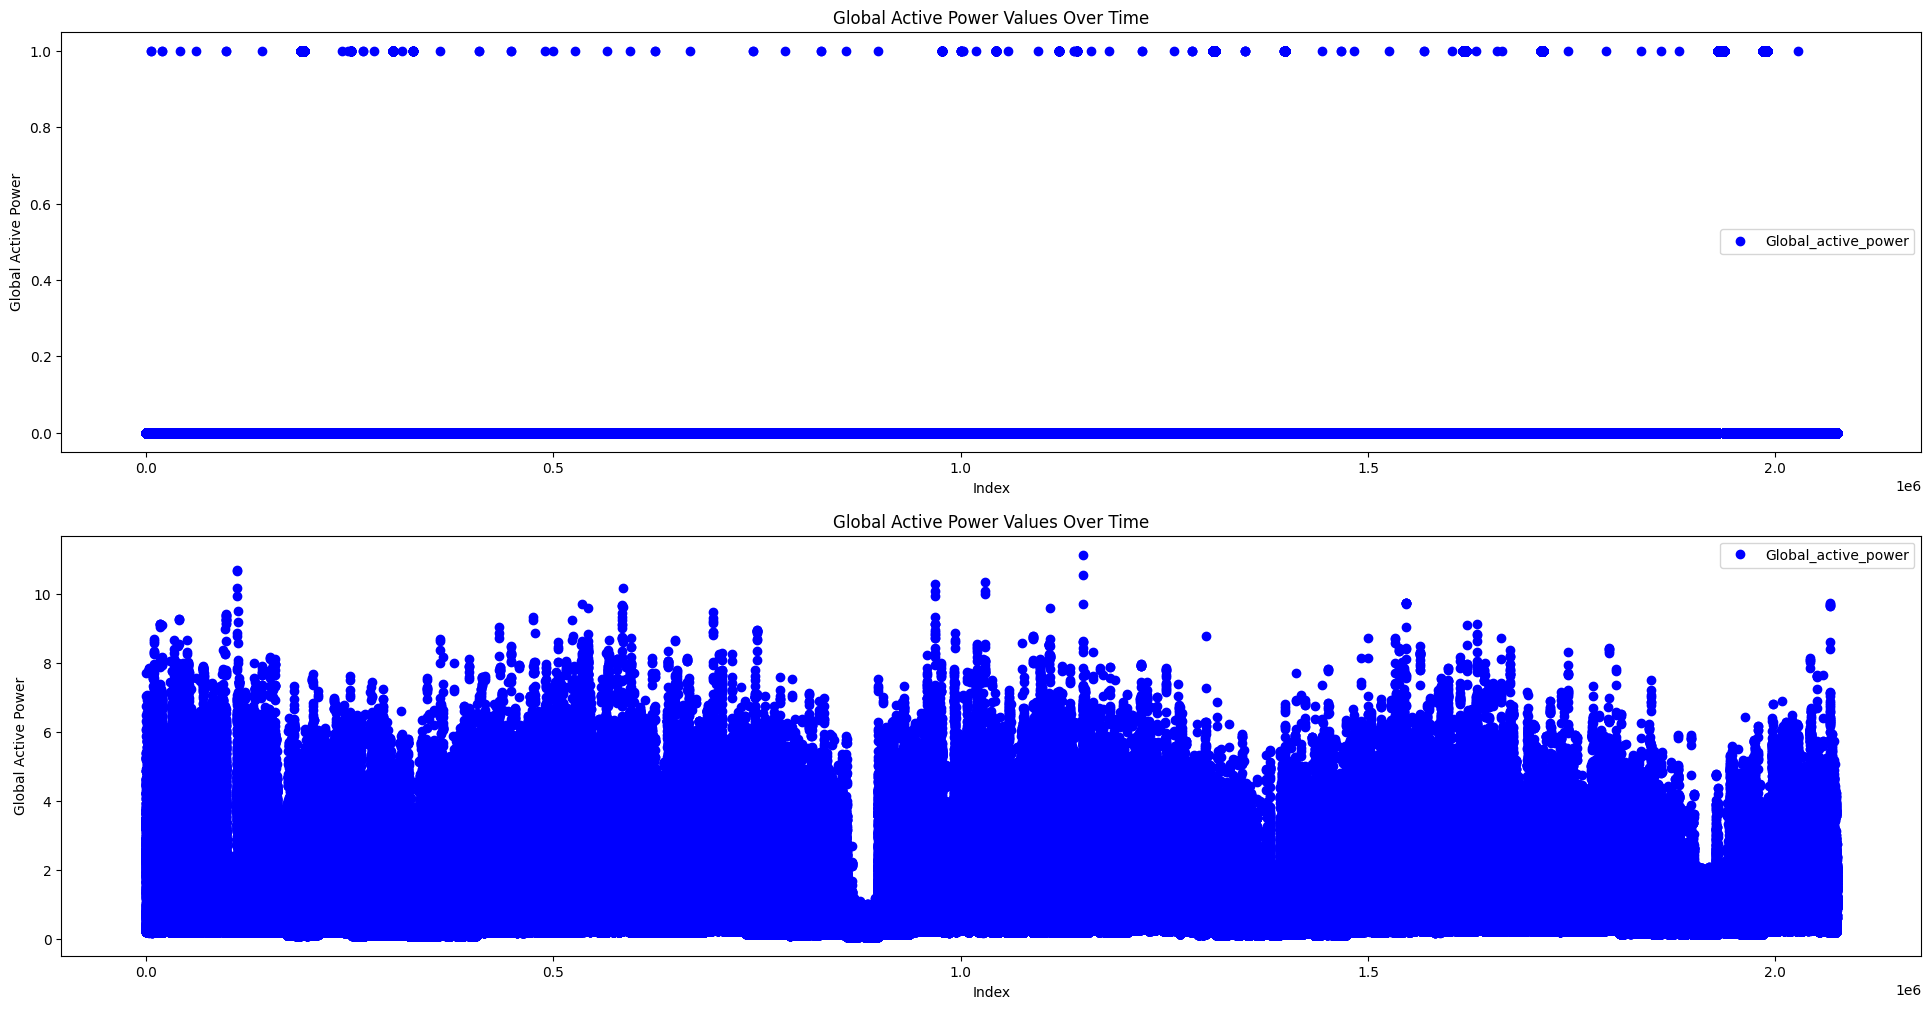

In [8]:
plt.figure(figsize=(24, 12))
plt.subplot(2, 1, 1)
plt.plot(df['Global_active_power'].isna(), label='Global_active_power', color='blue', marker='o', linestyle='None')
plt.title('Global Active Power Values Over Time')
plt.xlabel('Index')
plt.ylabel('Global Active Power')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(df['Global_active_power'], label='Global_active_power', color='blue', marker='o', linestyle='None')
plt.title('Global Active Power Values Over Time')
plt.xlabel('Index')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()


For filling missing values, we are going to adopt two strategies. First we will aggregate the minute-level data into hour level data, this will automatically ignore any gaps less than an hours. Then hours that are still NaN will be imputed, but only up to 6 hours to ensure that data is not created where it should not be.

In [9]:
# Create datatime index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.set_index('Datetime').sort_index()

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
numeric_columns = ['Global_active_power','Global_reactive_power','Voltage',
                   'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
hourly = df[numeric_columns].resample('h').mean()

hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [11]:
hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34168 non-null  float64
 1   Global_reactive_power  34168 non-null  float64
 2   Voltage                34168 non-null  float64
 3   Global_intensity       34168 non-null  float64
 4   Sub_metering_1         34168 non-null  float64
 5   Sub_metering_2         34168 non-null  float64
 6   Sub_metering_3         34168 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


In [12]:
hourly.isna().sum()

,0
Global_active_power,421
Global_reactive_power,421
Voltage,421
Global_intensity,421
Sub_metering_1,421
Sub_metering_2,421
Sub_metering_3,421


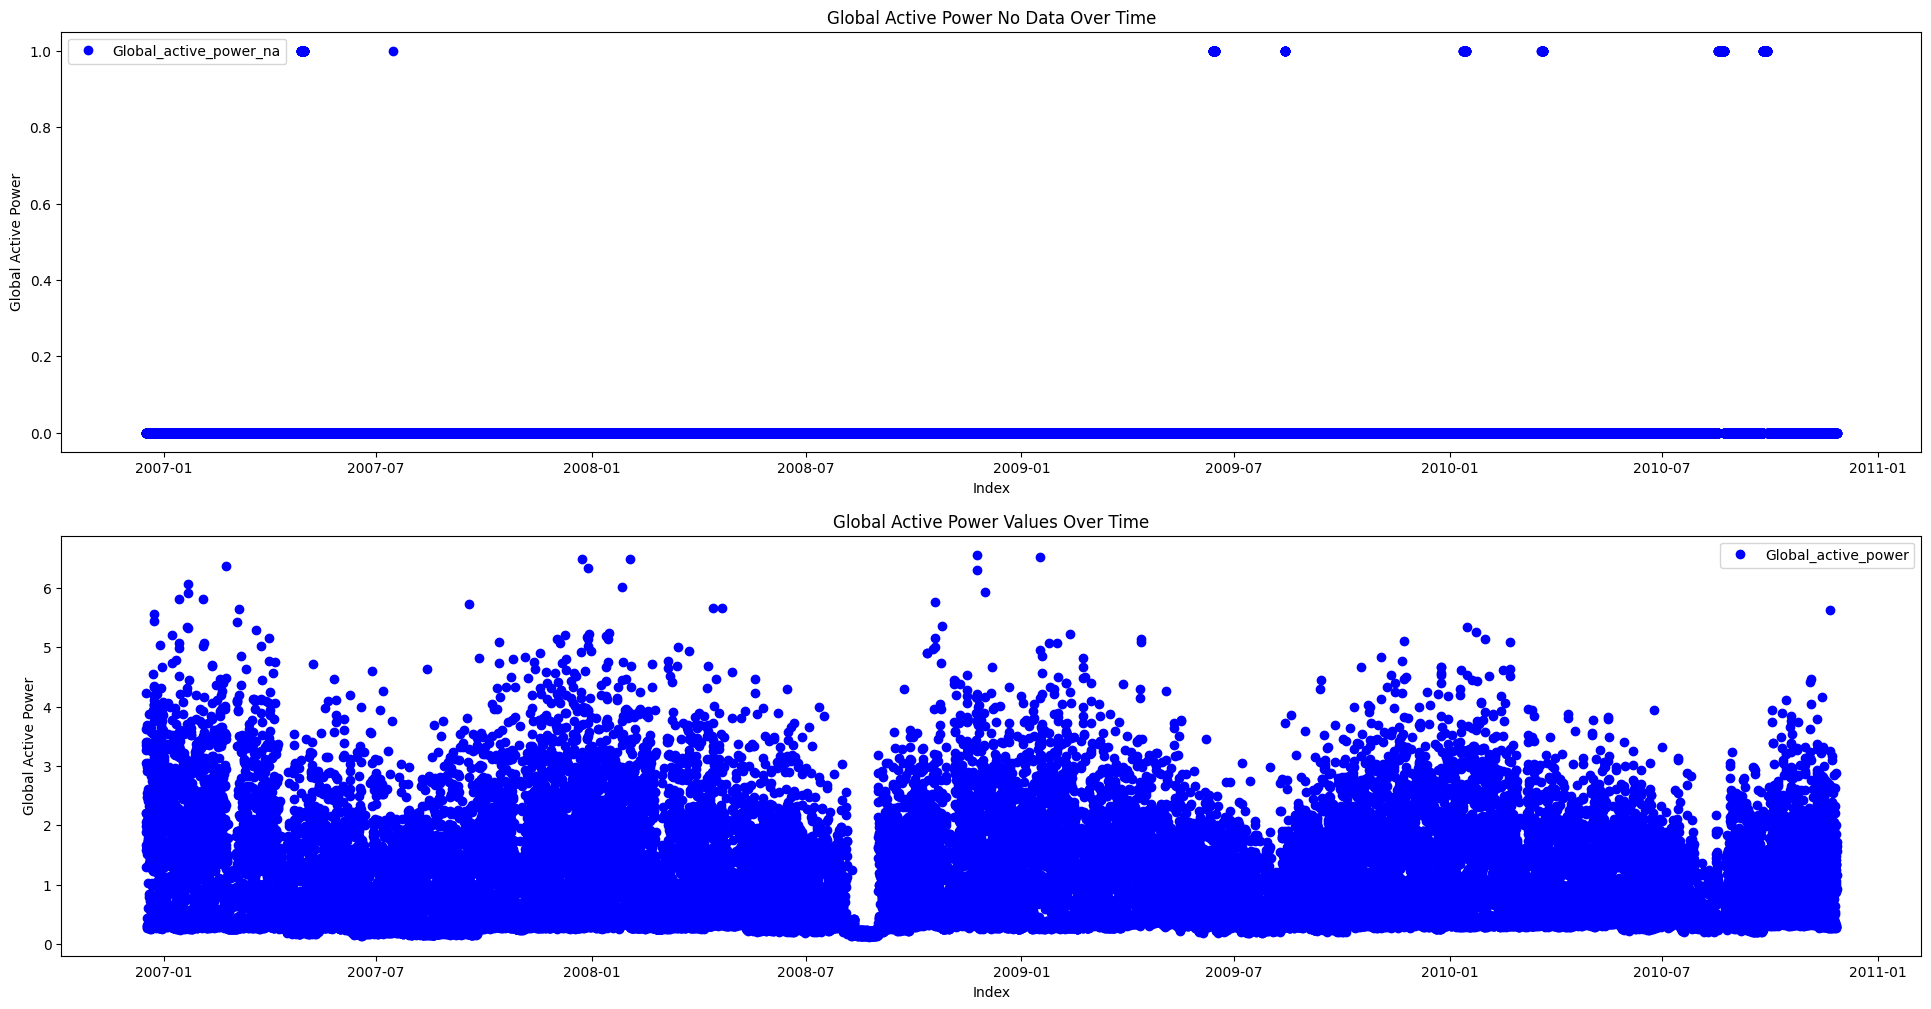

In [13]:
plt.figure(figsize=(24, 12))
plt.subplot(2, 1, 1)
plt.plot(hourly['Global_active_power'].isna(), label='Global_active_power_na', color='blue', marker='o', linestyle='None')
plt.title('Global Active Power No Data Over Time')
plt.xlabel('Index')
plt.ylabel('Global Active Power')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(hourly['Global_active_power'], label='Global_active_power', color='blue', marker='o', linestyle='None')
plt.title('Global Active Power Values Over Time')
plt.xlabel('Index')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()

Now that we've resampled and removed the small gaps, we'll interpolate bigger gaps up to 6 hours. Longer gaps are left as NaN to avoid representing larger trends with straight lines.

In [14]:
hourly = hourly.interpolate(
    method='time',
    limit=6,
    limit_direction='both'
)

In [15]:
hourly.isna().sum()

,0
Global_active_power,336
Global_reactive_power,336
Voltage,336
Global_intensity,336
Sub_metering_1,336
Sub_metering_2,336
Sub_metering_3,336


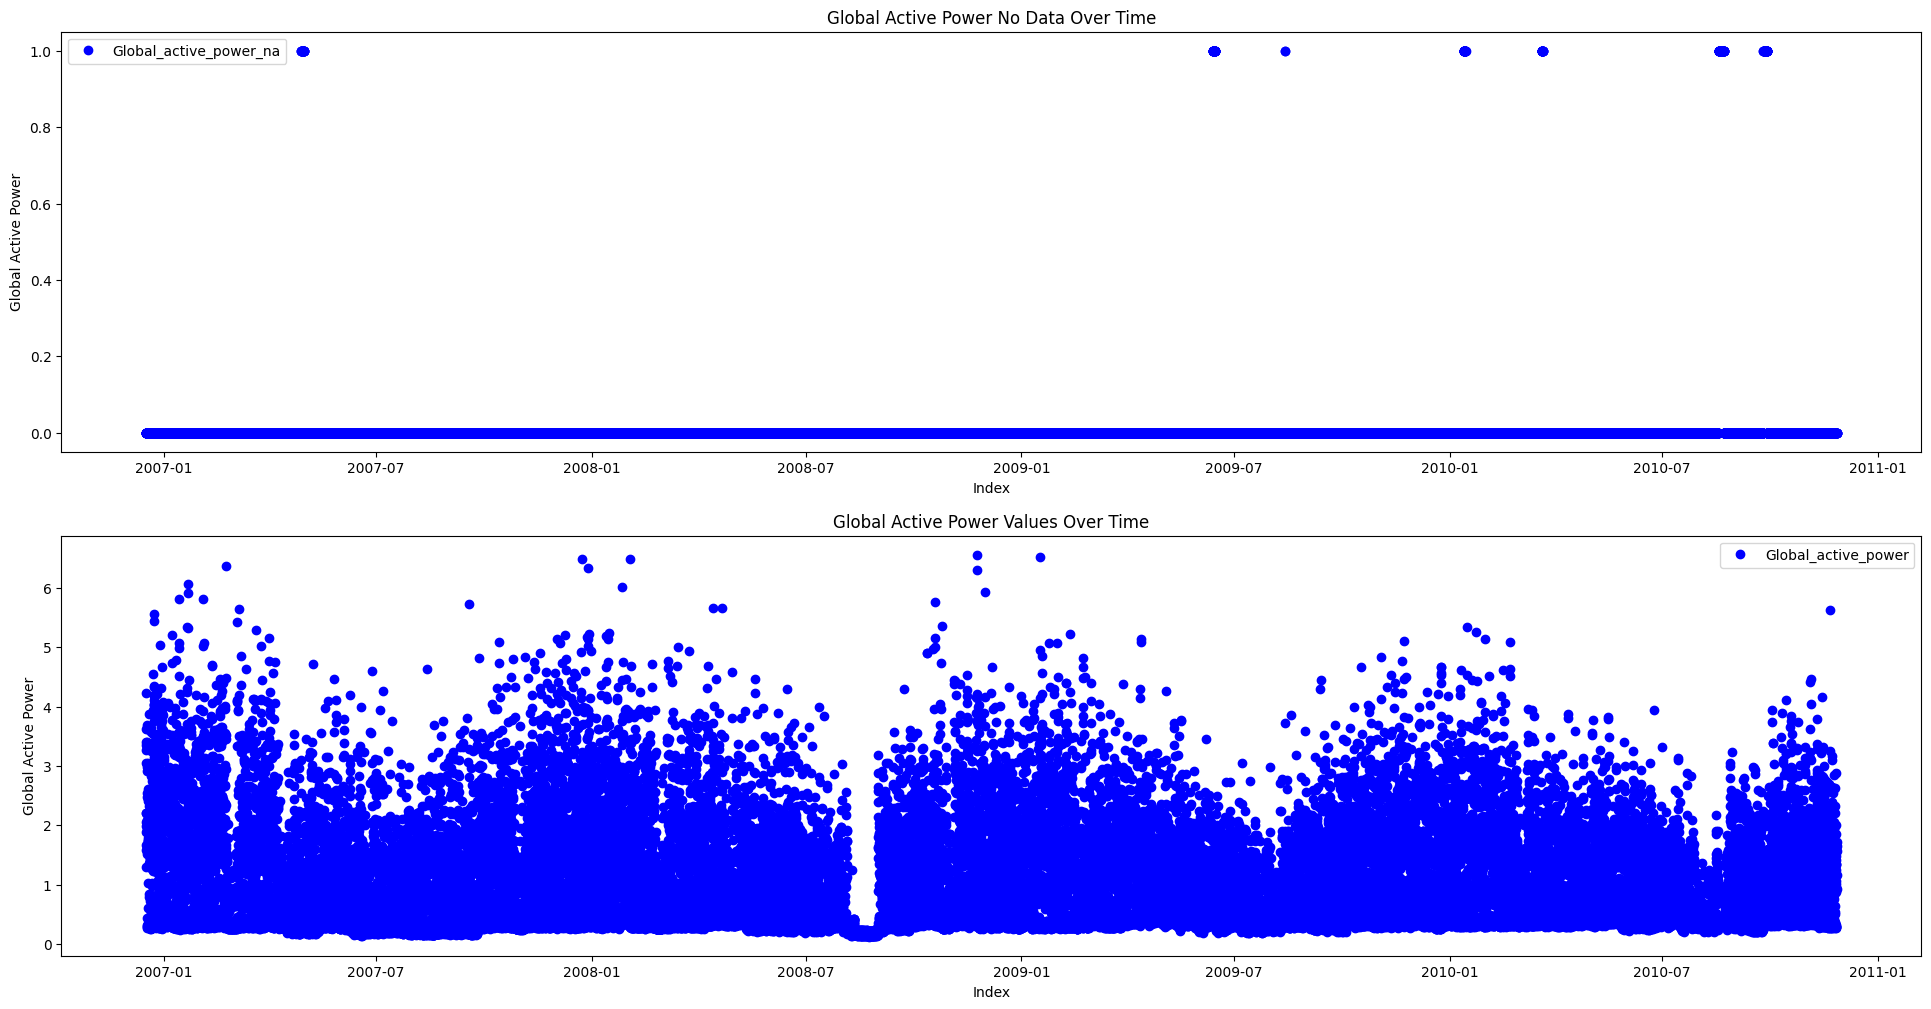

In [16]:
plt.figure(figsize=(24, 12))
plt.subplot(2, 1, 1)
plt.plot(hourly['Global_active_power'].isna(), label='Global_active_power_na', color='blue', marker='o', linestyle='None')
plt.title('Global Active Power No Data Over Time')
plt.xlabel('Index')
plt.ylabel('Global Active Power')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(hourly['Global_active_power'], label='Global_active_power', color='blue', marker='o', linestyle='None')
plt.title('Global Active Power Values Over Time')
plt.xlabel('Index')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()

## Batching Data for LSTM

Take the continuous data and split it into batches of 168 hours of feature data and 24 hours of target data. Exclude any stretches containing NaN

In [19]:
INPUT_HOURS = 168
TARGET_HOURS = 24

FEATURES = numeric_columns
TARGET = ['Global_active_power']

def window(df, 
           target=TARGET,
           features=FEATURES, 
           input_hours=INPUT_HOURS, 
           target_hours=TARGET_HOURS):
       span = input_hours + target_hours
       feats = df[features].to_numpy()
       targ = df[target].to_numpy()
       times = df.index

       valid = ~np.isnan(feats).any(axis=1)

       run = np.zeros(len(valid), dtype=np.int64)
       c=0
       for j, v in enumerate(valid):
              if v:
                     c += 1
              else:
                     c = 0
              run[j] = c

       # a valid run reaches length `span` at the position where the span ENDS
       ends = np.where(run >= span)[0]

       # the window start is `span` rows back from that end
       starts = ends - span + 1

       X = np.stack([feats[s:s + input_hours] for s in starts]).astype('float32')
       y = np.stack([targ[s + input_hours: s + span] for s in starts]).astype('float32')

       input_start_times = times[starts]
       target_start_times = times[starts + input_hours]

       return X, y, input_start_times, target_start_times

In [20]:
# Build the windows over the full cleaned series
X, y, input_start_times, forecast_start_times = window(hourly)

print(f"X shape: {X.shape}   (samples, {INPUT_HOURS} input hours, {len(FEATURES)} features)")
print(f"y shape: {y.shape}   (samples, {TARGET_HOURS} forecast hours)")
print(f"samples kept: {X.shape[0]:,}  of {len(hourly) - INPUT_HOURS + TARGET_HOURS + 1:,} possible 192-hour positions")

# Sanity checks: no NaN anywhere, and every span is truly contiguous (192 hours end-to-end)
assert not np.isnan(X).any(), "X contains NaN"
assert not np.isnan(y).any(), "y contains NaN"
span_len = (forecast_start_times + pd.Timedelta(hours=TARGET_HOURS)) - input_start_times
assert (span_len == pd.Timedelta(hours=INPUT_HOURS + TARGET_HOURS)).all(), "a window is not a continuous 192-hour span"
print("\nAll windows are continuous 192-hour spans with no NaN.")


X shape: (32725, 168, 7)   (samples, 168 input hours, 7 features)
y shape: (32725, 24, 1)   (samples, 24 forecast hours)
samples kept: 32,725  of 34,446 possible 192-hour positions

All windows are continuous 192-hour spans with no NaN.


In [21]:
import re
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


Split into training and testing data: last 6 months -> testing

Then create torch tensors

In [23]:
from dateutil.relativedelta import relativedelta
last_date = hourly.index[-1]
cutoff = last_date - relativedelta(months=6)
print(cutoff)

2010-05-26 21:00:00


In [24]:
train_df = hourly.loc[:cutoff]
test_df = hourly.loc[cutoff + pd.Timedelta(hours=1):]

X_train, y_train, train_times, train_forecast_times = window(train_df)
X_test, y_test, test_times, test_forecast_times = window(test_df)

In [25]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

Defining the LSTM Model

In [ ]:
class LSTM(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size=64,
            num_layers=2,
            output_size = TARGET_HOURS,
            dropout = 0.2
    ):
        super.__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)
